# Image processing: information for week 8

In [4]:
import numpy as np
import matplotlib.pyplot as plt

###  What are images?

An image is a 2D grid of data, each element of the grid is one pixel. We'll start off by considering black and white images, which have a single number per pixel. When you display the images in matplotlib, it displays 0 as black, and the largest number in the image as white, and everything else inbetween is shades of grey.

You can make a 2D grid of date using lists of lists. The first image has black in the top, left corner, white in the bottom right and a gradient inbetween:

In [6]:
image = [
    [ 0, 1, 2, 3, 4, 5],
    [ 1, 2, 3, 4, 5, 6],  
    [ 2, 3, 4, 5, 6, 7],  
    [ 3, 4, 5, 6, 7, 8],
    [ 4, 5, 6, 7, 8, 9],
    [ 5, 6, 7, 8, 9,10]]

You can display images using `plt.imshow`. You need to use `cmap` in order to tell python to plot 0 as black and the largest number as white. It has many other colour maps available which you can use to get more contrast, and these are very useful for imaging of cells.

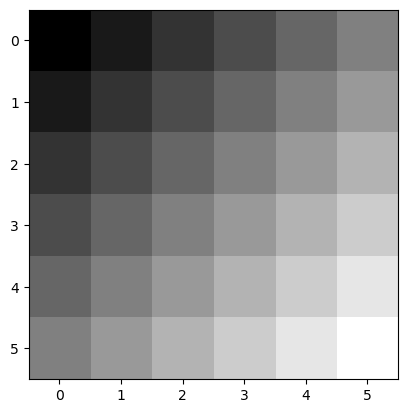

In [8]:
plt.imshow(image, cmap="gray")
plt.show()

Here's another example. Images don't need to be square and the images look similar to how the lists are written down: the innermost lists correspond to pixels going left to right, and the outermost list correspond to rows going top to bottom.

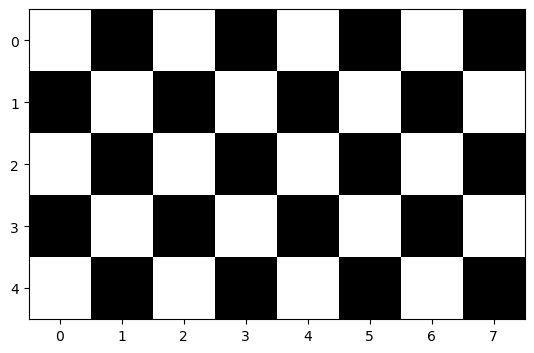

In [10]:
chequerboard = [
    [1,0,1,0,1,0,1,0],
    [0,1,0,1,0,1,0,1],
    [1,0,1,0,1,0,1,0],
    [0,1,0,1,0,1,0,1],
    [1,0,1,0,1,0,1,0],
]
plt.imshow(chequerboard, cmap="gray")
plt.show()

You can also generate images using for loops

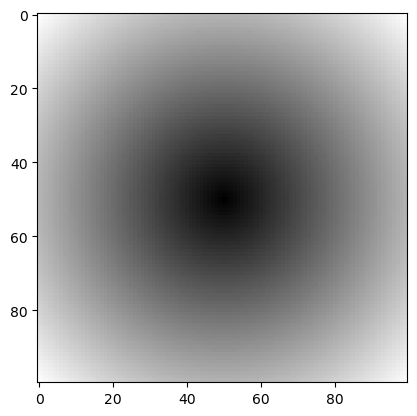

In [21]:
#Start with an image filled with zeros. Remember * for a list makes
#copies.
size=100

image=[]
for row in range(0,size):
    image.append([])
    for column in range(0,size):
        image[row].append(0)

# Draw a circular shape centred on the middle of the image
for row in range(0,size):
    for column in range(0,size):
        radius = ((row-50)**2 + (column - 50)**2)**.5
        image[column][row] = radius
plt.imshow(image, cmap="gray")
plt.show()

Once you have images with gradients, colourmaps can be useful. Note that colourmaps are not the same as colour images. Instead of black for 0 and white for the largest number, with shades of gray in between, colourmaps let you have different colours at the and and other shades inbetween. Here are some examples. Note, this is the same image each time,, just with a different way of visualising it.

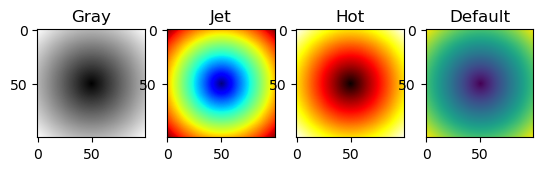

In [23]:
plt.subplot(1,4,1)
plt.imshow(image, cmap="gray")
plt.title("Gray")
plt.subplot(1,4,2)
plt.imshow(image, cmap="jet")
plt.title("Jet")
plt.subplot(1,4,3)
plt.imshow(image, cmap="hot")
plt.title("Hot")
plt.subplot(1,4,4)
plt.imshow(image)
plt.title("Default")
plt.show()

Jet (popular with engineers) and Hot (popular with biologists) are particularly good at showing contrast, because they have four colour transitions compared to just one for grey.

### Loading images

Python can also load images from files. It's easy to do, but there are a few odd things which make it quite tricky to get right. Let's start with loading a JPEG file.

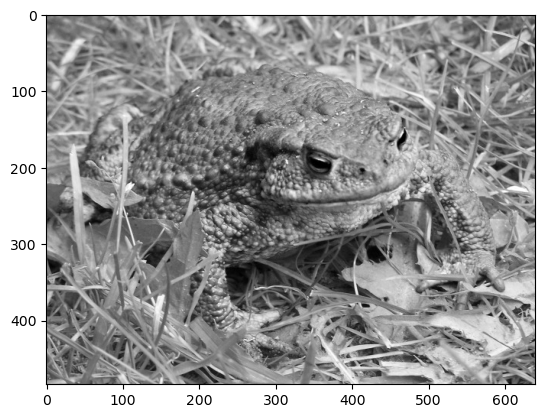

Maximum value in the image:  255


In [25]:
toad = plt.imread('bufo_bufo.jpg')
plt.imshow(toad, cmap="gray")
plt.show()
print("Maximum value in the image: ", toad.max())

It look exactly like it does if you just open the image. An important thing to note is that the maximum value is 255. Image files are a bit different from python. In python, 0 is black and the maximum value in the image is white. In image files such as JPEG, 0 is black and 255 is white. This is because JPEG images have an 8 bit binary number for each pixel and the maximum value of an 8 bit binary number is 11111111 in binary which is 255 in decimal. This can cause some problems:

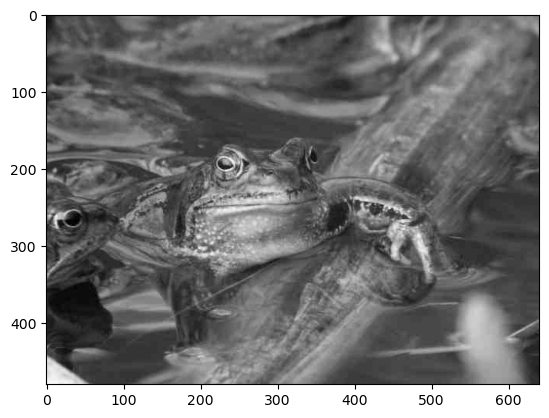

Maximum value in the image:  64


In [27]:
frog = plt.imread("rana_temporaria.jpg")
plt.imshow(frog, cmap="gray")
plt.show()
print("Maximum value in the image: ", frog.max())

If you open the image by clicking on the file, you will see that it is much much darker than it appears in python. That's because for JPEG images, 255 means white, but in python, the maximum value means white and the maximum value is only 34. So python is displaying 34 as white, when really 34 should be dark gray.

You can fix this using the `vmax` parameter (short for "value maximum") which tells python which number it should use for white instead of the largest number in the image. When you use this, the image looks the same as it appears when you click on it.

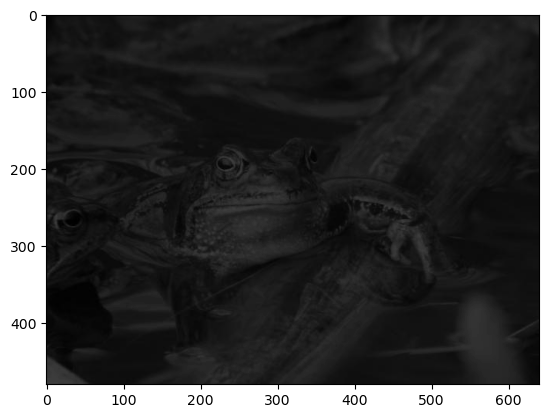

In [20]:
plt.imshow(frog, cmap="gray", vmax=255)
plt.show()

Unfortunately python is not very consistent, and treats different image formats differently. I have a PNG of exactly the same image, but python loads it differently from JPEG. Instead of white being 255, it's 1.0:

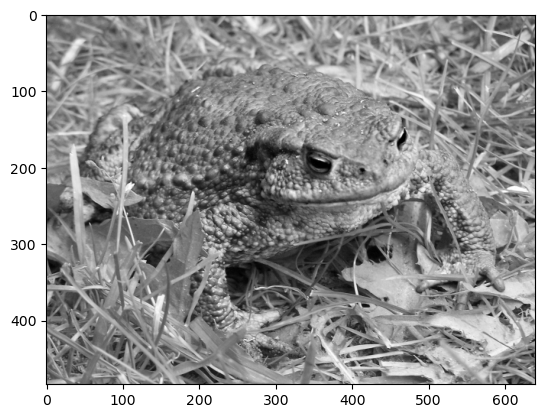

Maximum value in the image:  1.0


In [22]:
toadpng = plt.imread('bufo_bufo.png')
plt.imshow(toadpng, cmap="gray")
plt.show()
print("Maximum value in the image: ", toadpng.max())

Watch out for this if you load images! From now on I'm going to stick with PNGs, for very good reasons which I'll get into later.

## Image processing
### Thresholding

The simplest image processing algorithm is thresholding. With thresholding, you pick a threshold and any pixel brighter than the threshold becomes 1 and any pixel darker becomes zero. I'm first going to write a function to make an empty, black image, becuse I'll need somewhere to store the results of the processed images:

In [39]:
def empty_image(rows, columns):
    empty=[]
    for i in range(rows):
        empty.append([0] * columns)
    return empty

Here is my function to threshold:

In [41]:
def threshold(image, threshold):
    rows = len(image)
    #All rows have the same number of columns, so use the first for convenience
    columns = len(image[0])
    result = empty_image(rows,columns)
    
    for row in range(rows):
        for column in range(columns):
            if image[row][column] > threshold:
                result[row][column] = 1
            else:
                result[row][column] = 0
    return result

Here's what the toad looks like with several different thresholds:

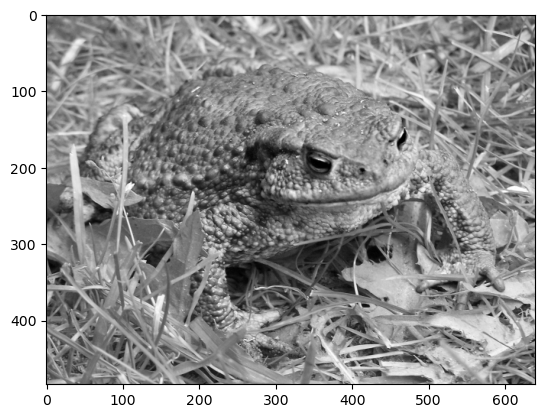

In [29]:
toad = plt.imread('bufo_bufo.png')
plt.imshow(toad, cmap="gray")
plt.show()

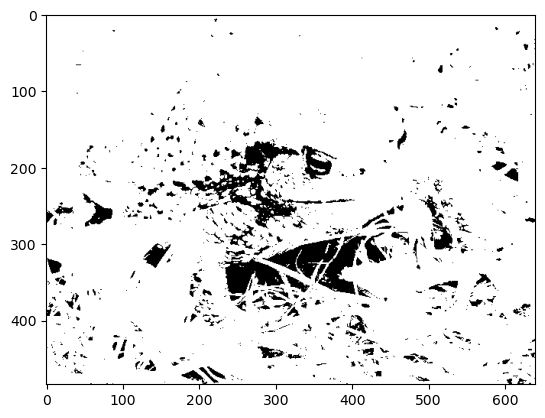

In [30]:
plt.imshow(threshold(toad, 0.25), cmap="gray")
plt.show()

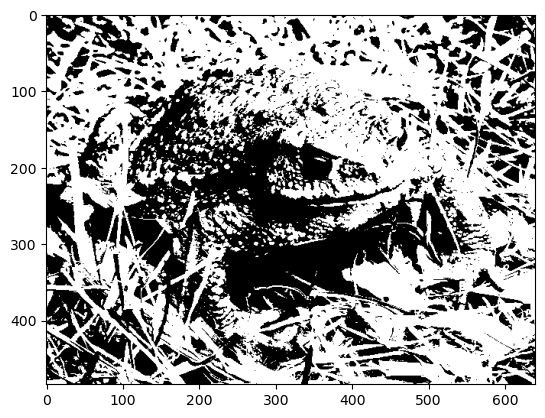

In [31]:
plt.imshow(threshold(toad, 0.5), cmap="gray")
plt.show()

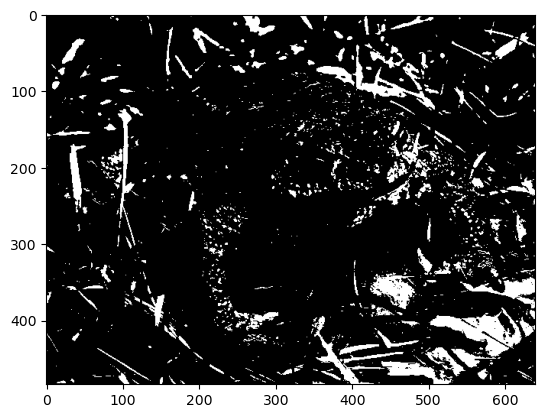

In [32]:
plt.imshow(threshold(toad, 0.75), cmap="gray")
plt.show()

## Annoying things you might need to know

The principle behind images is straightforward. However, if you ever write code to deal with images there are a number of tricky details which may result in rather odd bugs. 

### Types

Images in Python are 2D grids of data. These can be represented as lists of lists and you've now seen examples of how to make images with lists of lists. However, when you load an image you actually get a different type:

In [33]:
print(type(toad))

<class 'numpy.ndarray'>


The type is an N-dimensional array from the "Numpy" module. As you have seen already in many ways this behaves exactly the same way as list of lists, and you couldn't tell in the code above (thresholding) that you weren't actually using a list of lists.

Python works with something called "duck typing". The name comes from the expression

> If it looks like a duck, swims like a duck, and quacks like a duck, then it probably is a duck.

While a `numpy.ndarray` isn't a list of lists, in many ways it behaves identically. You can use `len` to find the length of the outermost list (number of rows). You can use `[]` to get one of the inner lists (a row), and then use `[]` again to get a value.

So why use `ndarray`, why not just use a list of lists?

For images `ndarray` has a number of advantages over lists of lists:
* Unlike lists of lists, every row has to be the same length (images must be rectangular)
* Each element of an ND array must be the same type (every element of a list)
* ndarray is much more efficient than a list of lists
* ndarray has a number of extra useful operations which lists of lists don't have. Many of these only make sense because every element is a number

For example:

In [35]:
#You can get the rows and columns in one go:
print("Size", len(toad), len(toad[0])) 
print("Size", toad.shape) #ndarray only


Size 484 640
Size (484, 640)


In [45]:
#You can make empty images much more easily
black1 = empty_image(len(toad), len(toad[0])) #Well it's one line now but I had to write the function
black2 = np.zeros(toad.shape)


There are some extra operations that work across the image without having to write loops, and that only really make sense for numbers, such as `max`, `min`, `mean` and `np.median`.

In [47]:
print('Brightest pixel', toad.max())

Brightest pixel 255


In [49]:
print('Dimmest pixel', toad.min())

Dimmest pixel 0


In [51]:
# Numpy is not all that consistent
# some things are methods and some things are functions. 
# as you can see, mean works by itself but for median I have to specify np.median
print('Different averages', toad.mean(), np.median(toad))

Different averages 133.7982018336777 137.0


Numpy also provides some slightly more convenient ways of indexing:

In [53]:
row = 426
column = 639
print("The bottom right pixel value is ", toad[row][column])
print("The bottom right pixel value is ", toad[row, column]) #numpy only

The bottom right pixel value is  42
The bottom right pixel value is  42


numpy is a *very* large library and provides a lot of useful things. Because of duck typing, you can think of it as a list of lists, and you don't need to know most of the things I just wrote about for the course. However when you look documentation up online, you will almost certainly encounter them.

There's one final thing you need to know about not because it's useful right now but because you might encounter it by accident and it will cause some strange bugs. And I said I'd come back to it.

#### Bits and bytes, JPGs and PNGs

Computers use binary, where each digit can be 0 or 1. The most basic unit of storage is a byte which is 8 bits. This is an integer between 0 and 255 inclusive. Most images are stored using 1 byte to reperesent the pixel level. Bytes are not very convenient, because they can hold values between 0 and 255 only, strange things happen if you add or subtract them and the results should be outside of that range.

If you use PNGs with matplotlib, you don't need to know about this.

Unfortunately if you load a JPG you get an image of bytes. There's a quick fix to make JPGs work just like PNGs:

In [55]:
# Load a JPG image. Then divide every pixel by 255 so the largest possible value in
# the image is 1, just like a png. This also has the effect of converting the image 
# from inconvenient bytes to floats which behave how you expect them to.
common_toad = plt.imread('bufo_bufo.jpg')/255.0
print(common_toad.max())

1.0


### Colour images

For black-and-white images, you have one number per pixel where 0 is black and 1 is white. For colour images, you have three numbers one each for red, green and blue. By convention that is the order, the first number is red, the second, green and the third, blue.

You can do this with a list of lists of lists or a list of lists of tuples (or numpy arrays with 3 dimensions where the size of the innermost one is 3).

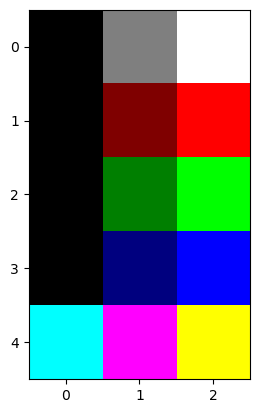

In [57]:
 colourimage = [
    [ (0,0,0), (.5, .5, .5), (1,1,1)],  #First row is black, grey, white
    [ (0,0,0), (.5,  0,  0), (1,0,0)],  #black, dark red, bright red
    [ (0,0,0), ( 0, .5,  0), (0,1,0)],  #black, dark green, bright green
    [ (0,0,0), ( 0,  0, .5), (0,0,1)],  #black, dark blue, bright blue
    [ (0,1,1), ( 1,  0,  1), (1,1,0)]   #cyan, magenta, yellow
   ]
plt.imshow(colourimage)
plt.show()

This is all well and good, but look at the first row. If all the colour values are they same, you get grey, and it's hard to tell the difference between a colour image where all the pixels have 3 values but are grey and a genuine grey image. For example:

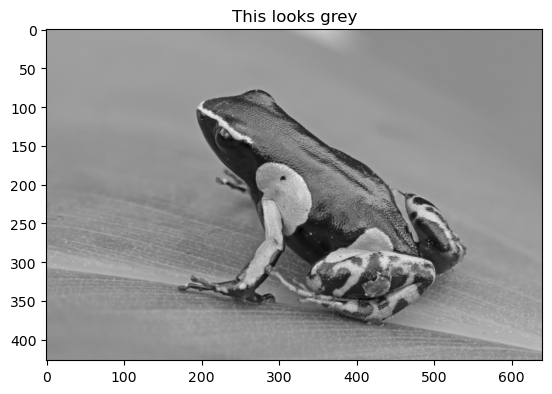

In [59]:
notgrey = plt.imread('mantella_baroni.png')
plt.imshow(notgrey)
plt.title("This looks grey")
plt.show()

But let's pick one pixel and see what value it has

In [61]:
print(notgrey[0][0])

[0.61960787 0.61960787 0.61960787]


The pixel has three identical values! This is actually a colour image where all of the colours just happen to be grey. If you've loaded images using imread, you can also check by looking at the shape:

In [63]:
print(notgrey.shape)

(427, 640, 3)


It's a colour image, because it has a third, innermost dimension of 3, corresponding to red, green and blue. You can just pick out one of the dimensions with a for loop if you want to get a grey image. The other option is using slicing.

### Slicing

Slicing works in the same way as it does for string, lists and lists of lists. You can use slicing for example to pick out one of the colours to make a grey image.

In [65]:
actuallygrey = notgrey[:][:][0] #All rows, all columns, first colour

If you're using numpy arrays rather than lists of lists, you can use commas instead of lots of square brackets, just like with indexing

In [67]:
actuallygrey = notgrey[:,:,0] #this means the same as above

You can also use slicing to cut out bits of an image

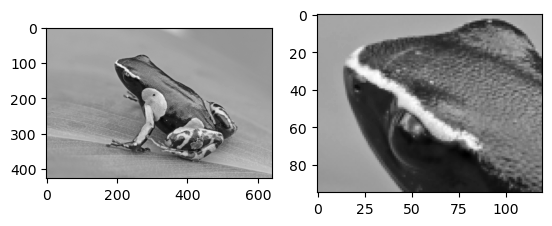

In [69]:
#Cut out a little fragment around the frog's head, using slicing
fragment = actuallygrey[75:170, 180:300]
plt.subplot(1,2,1)
plt.imshow(actuallygrey, cmap="gray")
plt.subplot(1,2,2)
plt.imshow(fragment, cmap="gray")
plt.show()